# ML Homework 5 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW5.ipynb" to "HW5_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together



** 6. Upload the saved 'Original vs Reconstructed Data' image files for both the worst and best models.

** 7. Upload the saved 'Latent Space Visualization (t-SNE)' image file for both the worst and best models.


# [HW 5] Grid Search for ConvAE and Visualization

1. Load your 'SoundSTFT.npy' file as you loaded in the 'ML10_Code1'.
2. Prepare training and test dataset with the test data ratio of """10%""".
3. Perform a grid search to find the best dimension of bottle neck layer for the ConvAE model.
  - You don't need to search other hyperparameters.

4. Determine your best and worst CNN model based on reconstruction error.
5. Compare original and reconstructed STFT spectrogram for both the worst and best models and save them as image files (.png or .jpg).
  - Upload the comparison images to BrightSpace with ipynb and pdf files

6. Extract latent space features from both the worst and best models and visualize them using t-SNE.
  - Save and upload the visualization results to BrightSpace as well.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
save_root = "/content/drive/MyDrive/Colab Notebooks/SavedFiles"

DataSet = np.load(os.path.join(save_root, "SoundSTFT.npy"))[:, :, :-1]
print("Loaded STFT dataset shape:", DataSet.shape)

Loaded STFT dataset shape: (623, 40, 704)


In [ ]:
cond = ['Tool Change', 'Chip Conveyer', 'Moving X axis', 'Moving Y axis', 'Moving Z axis', 'Spindle Movement']
NoOfData = [96, 161, 144, 41, 34, 147]
num_class = len(cond)

print("Number of classes:", num_class)
print("Samples in each class:", NoOfData)
print("Total samples:", sum(NoOfData))

Number of classes: 6
Samples in each class: [96, 161, 144, 41, 34, 147]
Total samples: 623


In [ ]:
n_samples, h, w = DataSet.shape
print("Original shape:", n_samples, h, w)

DataSet_2d = DataSet.reshape(n_samples, -1)

scaler = MinMaxScaler()
DataSet_scaled = scaler.fit_transform(DataSet_2d).reshape(n_samples, h, w)

print("Scaled data shape:", DataSet_scaled.shape)

Original shape: 623 40 704
Scaled data shape: (623, 40, 704)


In [ ]:
IMG_SIZE = 128

X = np.array([
    tf.image.resize(DataSet_scaled[i][..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy()
    for i in range(n_samples)
], dtype=np.float32)

print("Resized dataset shape:", X.shape)

Resized dataset shape: (623, 128, 128, 1)


In [ ]:
datasets = []
labels = []

start = 0
for class_id, count in enumerate(NoOfData):
    class_data = X[start:start+count]
    class_label = np.full(count, class_id)

    datasets.append(class_data)
    labels.append(class_label)

    start += count

for i in range(num_class):
    print(f"Class {i} ({cond[i]}):", datasets[i].shape, labels[i].shape)

Class 0 (Tool Change): (96, 128, 128, 1) (96,)
Class 1 (Chip Conveyer): (161, 128, 128, 1) (161,)
Class 2 (Moving X axis): (144, 128, 128, 1) (144,)
Class 3 (Moving Y axis): (41, 128, 128, 1) (41,)
Class 4 (Moving Z axis): (34, 128, 128, 1) (34,)
Class 5 (Spindle Movement): (147, 128, 128, 1) (147,)


In [ ]:
TEST_RATIO = 0.10

TrainData_list = []
TestData_list = []
TrainLabel_list = []
TestLabel_list = []

for class_id in range(num_class):
    X_train, X_test, y_train, y_test = train_test_split(
        datasets[class_id],
        labels[class_id],
        test_size=TEST_RATIO,
        random_state=777
    )

    TrainData_list.append(X_train)
    TestData_list.append(X_test)
    TrainLabel_list.append(y_train)
    TestLabel_list.append(y_test)

TrainData = np.concatenate(TrainData_list, axis=0)
TestData  = np.concatenate(TestData_list, axis=0)
TrainLabel = np.concatenate(TrainLabel_list, axis=0)
TestLabel  = np.concatenate(TestLabel_list, axis=0)

print("TrainData shape:", TrainData.shape)
print("TestData shape :", TestData.shape)
print("TrainLabel shape:", TrainLabel.shape)
print("TestLabel shape :", TestLabel.shape)

TrainData shape: (557, 128, 128, 1)
TestData shape : (66, 128, 128, 1)
TrainLabel shape: (557,)
TestLabel shape : (66,)


In [ ]:
def build_convae(input_shape=(128, 128, 1), bottleneck_dim=32):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)   # 64x64

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)   # 32x32

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)   # 16x16

    shape_before_flatten = keras.backend.int_shape(x)[1:]
    x = layers.Flatten()(x)

    latent = layers.Dense(bottleneck_dim, name='latent_vector')(x)

    # Decoder
    x = layers.Dense(int(np.prod(shape_before_flatten)), activation='relu')(latent)
    x = layers.Reshape(shape_before_flatten)(x)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)   # 32x32
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)   # 64x64
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(x)   # 128x128

    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(inputs, outputs, name=f"ConvAE_bn{bottleneck_dim}")
    encoder = keras.Model(inputs, latent, name=f"Encoder_bn{bottleneck_dim}")

    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder

In [ ]:
build_convae(input_shape=TrainData.shape[1:], bottleneck_dim=8

(<Functional name=ConvAE_bn8, built=True>,
 <Functional name=Encoder_bn8, built=True>)

In [ ]:
bottleneck_list = [8, 16, 32, 64, 128]

results = {}
models = {}
encoders = {}
histories = {}

for bn_dim in bottleneck_list:
    print("="*50)
    print(f"Training model with bottleneck dimension = {bn_dim}")

    model, encoder = build_convae(
        input_shape=TrainData.shape[1:],
        bottleneck_dim=bn_dim
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        TrainData, TrainData,
        validation_data=(TestData, TestData),
        epochs=30,
        batch_size=16,
        verbose=1,
        callbacks=[early_stop]
    )

    reconstructed = model.predict(TestData, verbose=0)

    sample_mse = np.mean((TestData - reconstructed) ** 2, axis=(1, 2, 3))
    mean_recon_error = np.mean(sample_mse)

    results[bn_dim] = mean_recon_error
    models[bn_dim] = model
    encoders[bn_dim] = encoder
    histories[bn_dim] = history.history

    print(f"Bottleneck {bn_dim} Mean Reconstruction Error = {mean_recon_error:.6f}")

Training model with bottleneck dimension = 8
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 843ms/step - loss: 0.1726 - val_loss: 4.7763e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 566ms/step - loss: 9.4732e-04 - val_loss: 4.7676e-04
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 546ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 593ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 40s 561ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 608ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 581ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Bottleneck 8 Mean Reconstruction Error = 0.000477
Training model with bottleneck dimension = 16
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 646ms/step - loss: 0.1422 - val_loss: 4.7676e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 569ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 3/30
3

Bottleneck 32 Mean Reconstruction Error = 0.000477
Training model with bottleneck dimension = 64
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 660ms/step - loss: 0.1649 - val_loss: 4.7679e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 582ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 582ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 640ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 594ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 600ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 555ms/step - loss: 9.4730e-04 - val_loss: 4.7676e-04
Bottleneck 64 Mean Reconstruction Error = 0.000477
Training model with bottleneck dimension = 128
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 591ms/step - loss: 0.2069 - val_loss: 9.0380e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 597ms/step 

In [ ]:
results_df = pd.DataFrame({
    "Bottleneck_dim": list(results.keys()),
    "Mean_Reconstruction_Error": list(results.values())
})

results_df = results_df.sort_values(by="Mean_Reconstruction_Error", ascending=True)
results_df.reset_index(drop=True, inplace=True)

results_df

,Bottleneck_dim,Mean_Reconstruction_Error
0,16,0.000477
1,32,0.000477
2,8,0.000477
3,64,0.000477
4,128,0.000477


In [ ]:
results_csv_path = os.path.join(save_root, "HW5_GridSearch_Results.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved:", results_csv_path)

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/HW5_GridSearch_Results.csv


In [ ]:
best_bn = min(results, key=results.get)
worst_bn = max(results, key=results.get)

best_model = models[best_bn]
worst_model = models[worst_bn]

best_encoder = encoders[best_bn]
worst_encoder = encoders[worst_bn]

print("Best bottleneck dimension :", best_bn)
print("Best reconstruction error :", results[best_bn])

print("Worst bottleneck dimension:", worst_bn)
print("Worst reconstruction error:", results[worst_bn])

Best bottleneck dimension : 16
Best reconstruction error : 0.0004767579
Worst bottleneck dimension: 8
Worst reconstruction error: 0.00047675858


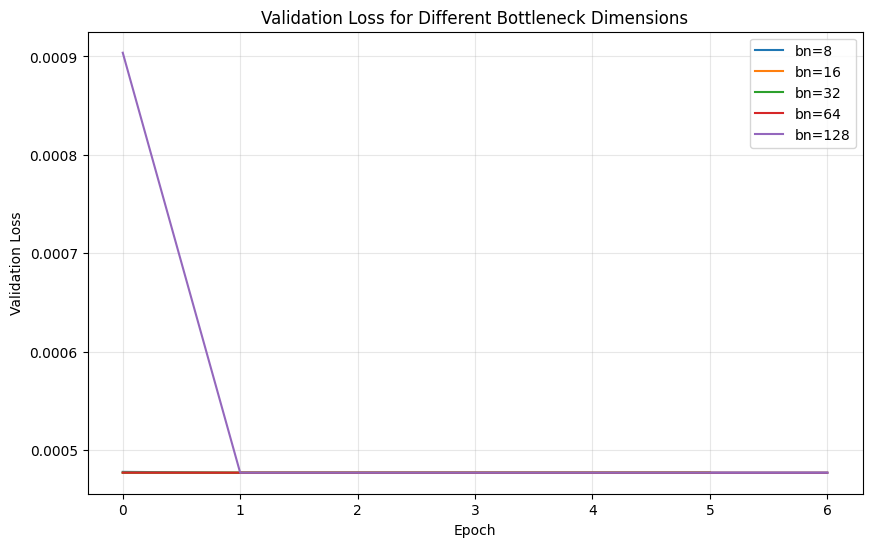

In [ ]:
plt.figure(figsize=(10, 6))

for bn_dim in bottleneck_list:
    plt.plot(histories[bn_dim]['val_loss'], label=f'bn={bn_dim}')

plt.title("Validation Loss for Different Bottleneck Dimensions")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def save_reconstruction_comparison(model, data, title, save_path, n_samples=5):
    reconstructed = model.predict(data[:n_samples], verbose=0)

    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3*n_samples))

    for i in range(n_samples):
        axes[i, 0].imshow(data[i].squeeze(), aspect='auto', origin='lower', cmap='jet')
        axes[i, 0].set_title(f"Original {i+1}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(reconstructed[i].squeeze(), aspect='auto', origin='lower', cmap='jet')
        axes[i, 1].set_title(f"Reconstructed {i+1}")
        axes[i, 1].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

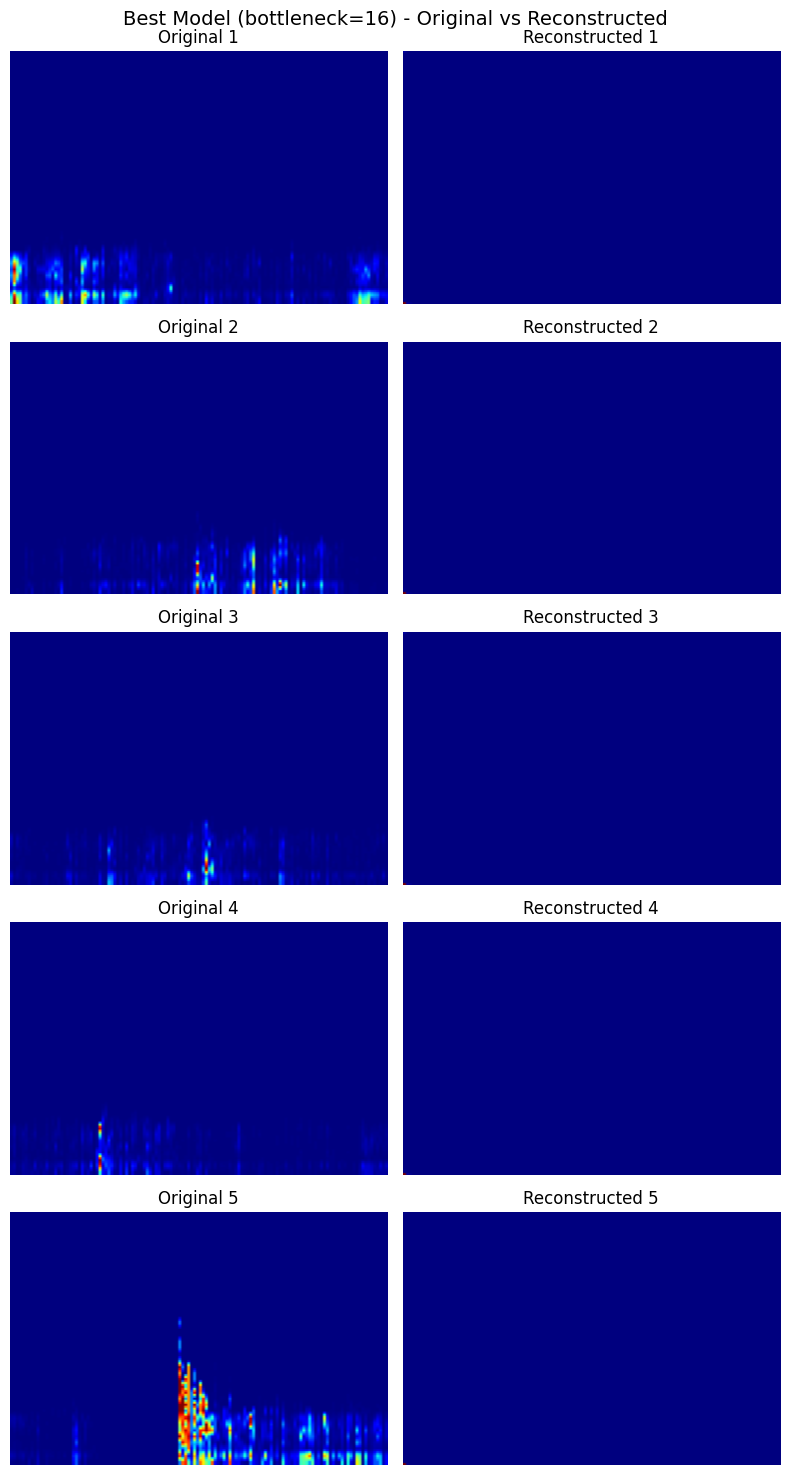

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/BestModel_Original_vs_Reconstructed.png


In [ ]:
best_recon_path = os.path.join(save_root, "BestModel_Original_vs_Reconstructed.png")

save_reconstruction_comparison(
    best_model,
    TestData,
    f"Best Model (bottleneck={best_bn}) - Original vs Reconstructed",
    best_recon_path,
    n_samples=5
)

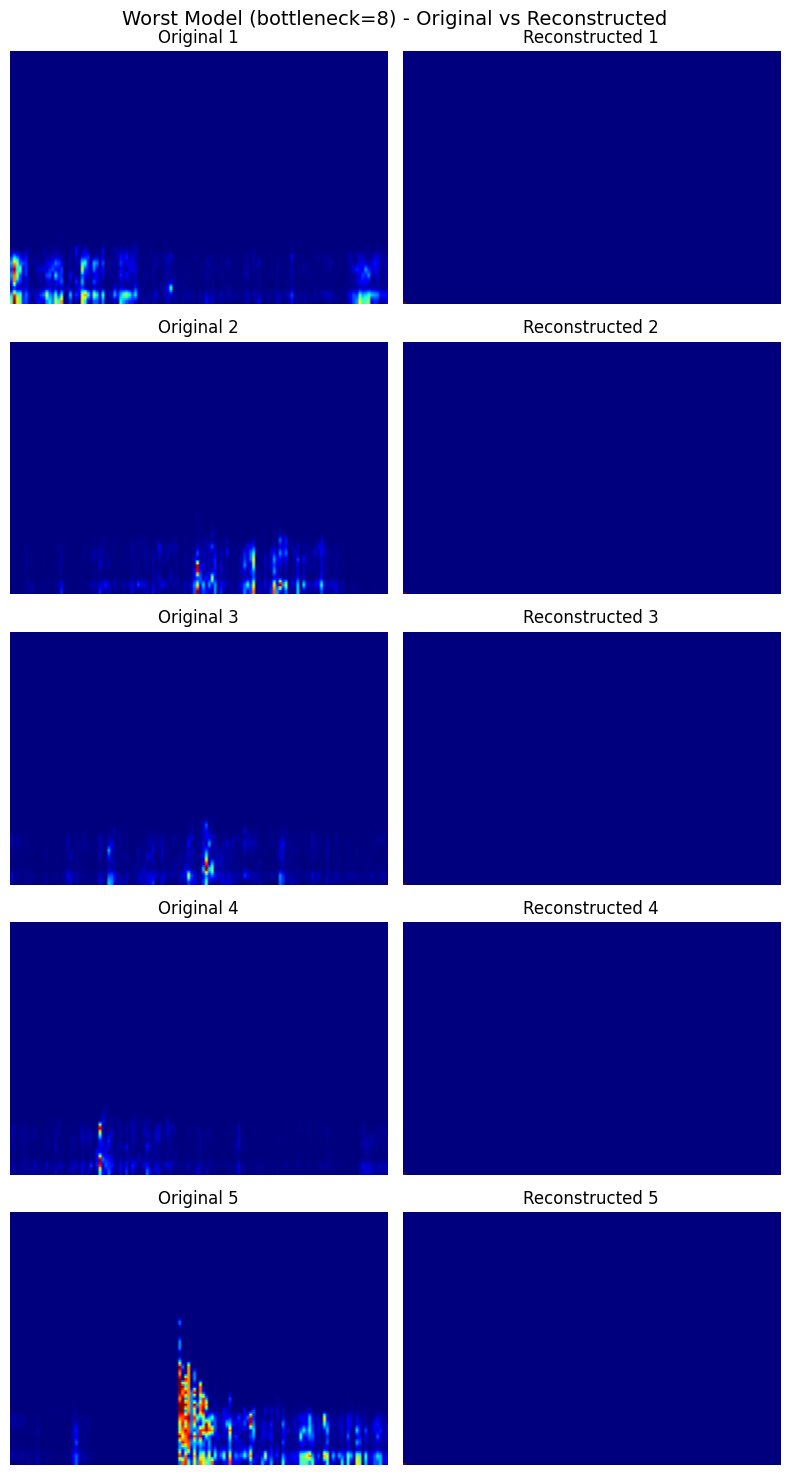

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/WorstModel_Original_vs_Reconstructed.png


In [ ]:
worst_recon_path = os.path.join(save_root, "WorstModel_Original_vs_Reconstructed.png")

save_reconstruction_comparison(
    worst_model,
    TestData,
    f"Worst Model (bottleneck={worst_bn}) - Original vs Reconstructed",
    worst_recon_path,
    n_samples=5
)

In [ ]:
def save_tsne_plot(encoder, data, labels, title, save_path):
    latent_features = encoder.predict(data, verbose=0)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=777,
        init='pca',
        learning_rate='auto'
    )

    latent_2d = tsne.fit_transform(latent_features)

    plt.figure(figsize=(8, 6))

    for class_id in range(num_class):
        idx = labels == class_id
        plt.scatter(
            latent_2d[idx, 0],
            latent_2d[idx, 1],
            label=cond[class_id],
            alpha=0.7
        )

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

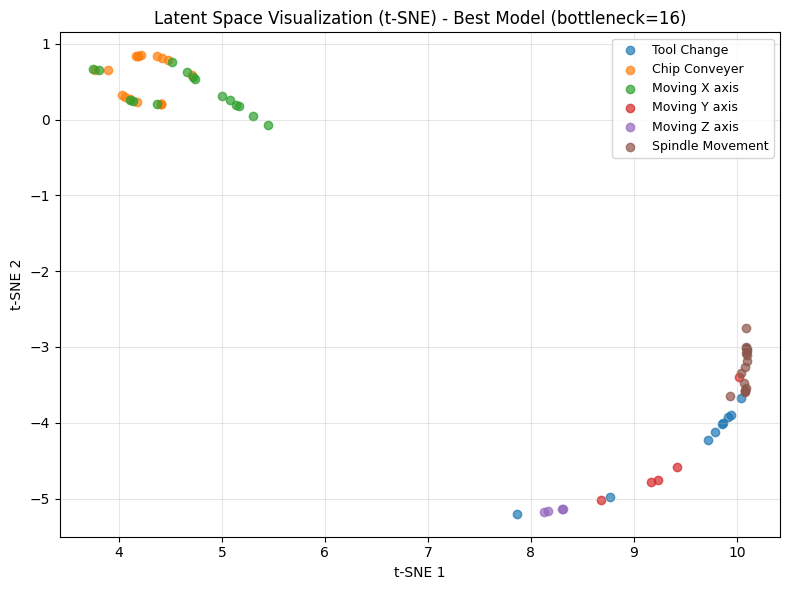

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/BestModel_tSNE.png


In [ ]:
best_tsne_path = os.path.join(save_root, "BestModel_tSNE.png")

save_tsne_plot(
    best_encoder,
    TestData,
    TestLabel,
    f"Latent Space Visualization (t-SNE) - Best Model (bottleneck={best_bn})",
    best_tsne_path
)

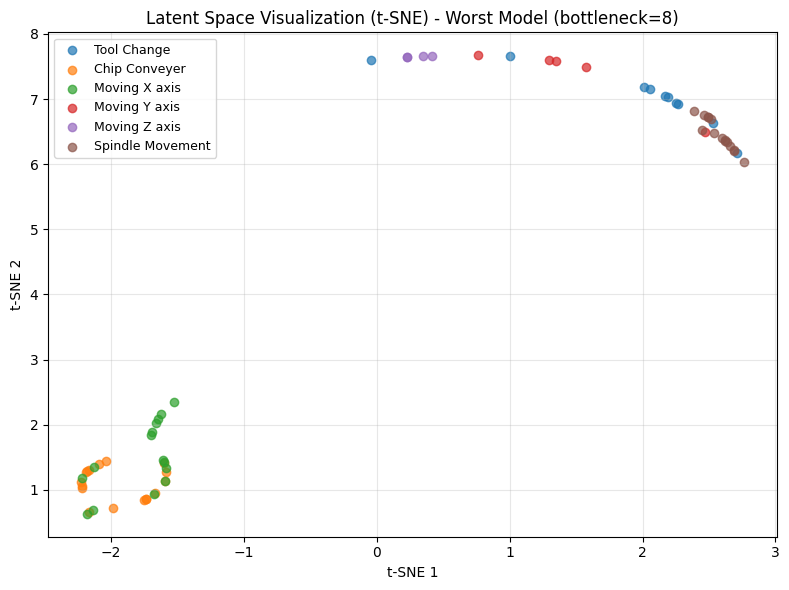

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/WorstModel_tSNE.png


In [ ]:
worst_tsne_path = os.path.join(save_root, "WorstModel_tSNE.png")

save_tsne_plot(
    worst_encoder,
    TestData,
    TestLabel,
    f"Latent Space Visualization (t-SNE) - Worst Model (bottleneck={worst_bn})",
    worst_tsne_path
)

In [ ]:
best_model_path = os.path.join(save_root, f"Best_ConvAE_bn{best_bn}.keras")
worst_model_path = os.path.join(save_root, f"Worst_ConvAE_bn{worst_bn}.keras")

best_model.save(best_model_path)
worst_model.save(worst_model_path)

print("Saved:", best_model_path)
print("Saved:", worst_model_path)

Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/Best_ConvAE_bn16.keras
Saved: /content/drive/MyDrive/Colab Notebooks/SavedFiles/Worst_ConvAE_bn8.keras


In [ ]:
print("="*60)
print("HW5 SUMMARY")
print("="*60)
print("Best bottleneck dimension :", best_bn)
print("Best reconstruction error :", results[best_bn])
print("Worst bottleneck dimension:", worst_bn)
print("Worst reconstruction error:", results[worst_bn])

print("\nSaved files:")
print(results_csv_path)
print(best_recon_path)
print(worst_recon_path)
print(best_tsne_path)
print(worst_tsne_path)
print(best_model_path)
print(worst_model_path)

HW5 SUMMARY
Best bottleneck dimension : 16
Best reconstruction error : 0.0004767579
Worst bottleneck dimension: 8
Worst reconstruction error: 0.00047675858

Saved files:
/content/drive/MyDrive/Colab Notebooks/SavedFiles/HW5_GridSearch_Results.csv
/content/drive/MyDrive/Colab Notebooks/SavedFiles/BestModel_Original_vs_Reconstructed.png
/content/drive/MyDrive/Colab Notebooks/SavedFiles/WorstModel_Original_vs_Reconstructed.png
/content/drive/MyDrive/Colab Notebooks/SavedFiles/BestModel_tSNE.png
/content/drive/MyDrive/Colab Notebooks/SavedFiles/WorstModel_tSNE.png
/content/drive/MyDrive/Colab Notebooks/SavedFiles/Best_ConvAE_bn16.keras
/content/drive/MyDrive/Colab Notebooks/SavedFiles/Worst_ConvAE_bn8.keras


### Conclusion

The ConvAE models with different bottleneck dimensions were evaluated using reconstruction error.
The model with the minimum reconstruction error was considered the best model, and the one with the maximum reconstruction error was considered the worst model.

Nevertheless, the difference between the best and worst reconstruction errors was very small.
This suggests that the bottleneck dimension had only a limited impact on model performance in this task.
Overall, all tested models showed very similar reconstruction capability on the STFT dataset.

Hence, while the grid search allowed comparison between models, the results indicate that all selected bottleneck sizes were effective and no single model showed a significantly superior performance.

## ML10 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML7 and ML8.

---

We loaded a WAV sound file and visualized the raw signal data. The sound was segmented into six machine operation classes using timestamp-based indexing. Each segment was further divided into overlapping windows for analysis. Time-domain and frequency-domain features were extracted from each segment. ANOVA (P-value) was used to select the most important features. Finally, STFT spectrograms were generated and prepared as input data for machine learning models.

---

### Q2. What skills did you have to develop to accomplish this project?

---

* Audio data preprocessing and segmentation
* Feature extraction (time & frequency domain)
* Understanding STFT and spectrograms
* Building and training deep learning models (ConvAE/CNN)
* Model evaluation and visualization (reconstruction error, t-SNE)


---

### Q3. What aspects of this project were the most beneficial for your learning?

---

* Gaining hands-on experience with real-world audio data processing
* Understanding how to convert signals into meaningful features (STFT, spectrograms)
* Learning how deep learning models (ConvAE/CNN) work on real datasets
* Interpreting model performance using reconstruction error and visualizations
* Connecting theory (signal processing + ML) with practical implementation

---

### Q4. What challenges did you encounter in completing the project?

---

* Difficulty in preprocessing and segmenting audio data correctly
* Understanding and implementing STFT and feature extraction
* Handling large datasets and managing memory in Colab
* Tuning model parameters (e.g., bottleneck size) for better performance
* Interpreting reconstruction error and visualization results


---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---



* Sought help from TAs and referred to lecture materials for clarity
* Used online documentation and tutorials to resolve coding issues
* Debugged step-by-step to identify and fix errors
* Verified results using plots and visualizations
* Experimented with different parameters to improve model performance


---